# Data Exploration — BTC/USDT OHLCV

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.loader import load_multiple, validate_continuity
from src.data.preprocessor import clean

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:,.2f}'.format)

Matplotlib is building the font cache; this may take a moment.


## 0. Run Data Pipeline

Run this cell once to generate `data/processed/` and `data/features/` files.
Skip if the files already exist.

In [ ]:
from pathlib import Path
from src.data.pipeline import run as run_pipeline

# Only re-run if output files are missing
if not Path('../data/features/train.csv').exists():
    print("Generating processed and feature files...")
    run_pipeline(config_path=Path('../configs/experiment_config.yaml'))
else:
    print("Pipeline output already exists — skipping. Delete data/features/ to re-run.")

## 1. Load Data

In [2]:
train_files = [f"../data/raw/BTCUSDT-1d-2024-{m:02d}.csv" for m in [8,9,10,11,12]]
val_files   = ["../data/raw/BTCUSDT-1d-2025-01.csv"]
test_files  = ["../data/raw/BTCUSDT-1d-2025-02.csv"]

train = load_multiple(train_files)
val   = load_multiple(val_files)
test  = load_multiple(test_files)

# Full combined view for EDA
all_data = pd.concat([train, val, test]).sort_index()

print(f"Total rows : {len(all_data)}")
print(f"Date range : {all_data.index[0].date()} → {all_data.index[-1].date()}")
print(f"\nSplit sizes:  train={len(train)}  val={len(val)}  test={len(test)}")

Total rows : 212
Date range : 2024-08-01 → 2025-02-28

Split sizes:  train=153  val=31  test=28


## 2. Basic Statistics

In [3]:
all_data.describe()

,open,high,low,close,volume
count,212.00,212.00,212.00,212.00,212.00
mean,"80,626.74","82,255.51","78,982.30","80,719.77","30,843.46"
std,"17,789.55","18,097.95","17,404.63","17,757.02","20,270.42"
min,"53,962.97","54,850.00","49,000.00","53,962.97","7,047.90"
25%,"62,460.99","63,464.39","61,655.69","62,461.00","19,054.32"
50%,"87,638.79","89,735.27","83,894.24","87,638.80","27,615.13"
75%,"97,208.00","98,790.32","95,428.83","97,208.00","37,174.93"
max,"106,143.82","109,588.00","105,321.49","106,143.82","162,065.59"


In [4]:
# Monthly summary — close price stats per month
monthly = all_data['close'].resample('ME').agg(['min','max','mean','std'])
monthly.index = monthly.index.strftime('%Y-%m')
monthly.columns = ['Min ($)', 'Max ($)', 'Mean ($)', 'Std Dev ($)']
monthly

,Min ($),Max ($),Mean ($),Std Dev ($)
open_time,,,,
2024-08,"54,018.81","65,354.02","59,907.67","2,543.52"
2024-09,"53,962.97","65,858.00","60,356.29","3,607.75"
2024-10,"60,326.39","72,736.42","65,612.62","3,652.78"
2024-11,"67,850.01","98,892.00","86,527.50","10,496.47"
2024-12,"92,792.05","106,133.74","98,258.43","3,437.63"
2025-01,"92,552.49","106,143.82","100,036.08","4,011.24"
2025-02,"84,250.09","101,328.52","95,279.23","4,448.48"


## 3. Price Chart with Train / Val / Test Splits

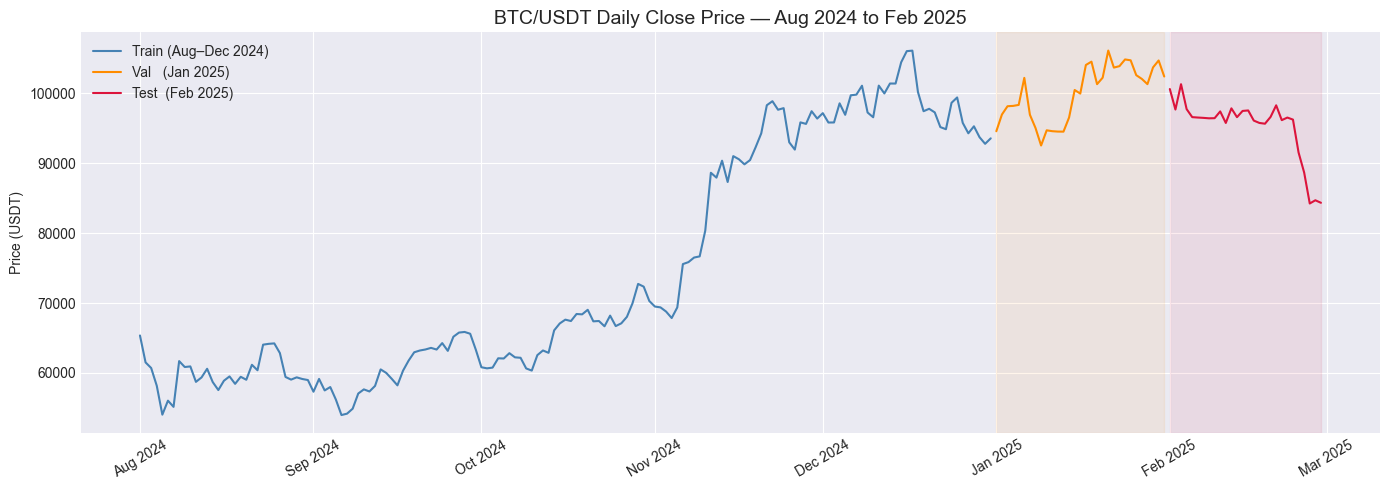

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, train['close'], color='steelblue',  label='Train (Aug–Dec 2024)', linewidth=1.5)
ax.plot(val.index,   val['close'],   color='darkorange', label='Val   (Jan 2025)',      linewidth=1.5)
ax.plot(test.index,  test['close'],  color='crimson',    label='Test  (Feb 2025)',       linewidth=1.5)

# Shade split boundaries
ax.axvspan(val.index[0],  val.index[-1],  alpha=0.08, color='darkorange')
ax.axvspan(test.index[0], test.index[-1], alpha=0.08, color='crimson')

ax.set_title('BTC/USDT Daily Close Price — Aug 2024 to Feb 2025', fontsize=14)
ax.set_ylabel('Price (USDT)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/01_price_splits.png', dpi=150)
plt.show()

## 4. Volume

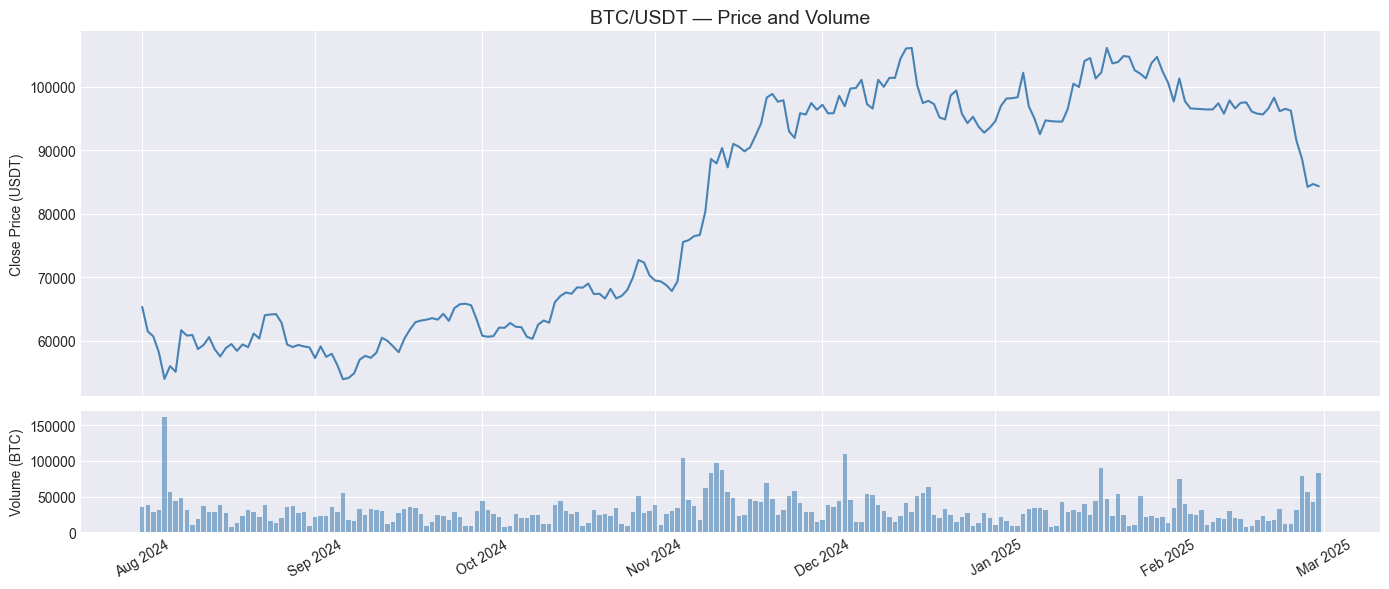

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(all_data.index, all_data['close'], color='steelblue', linewidth=1.5)
ax1.set_ylabel('Close Price (USDT)')
ax1.set_title('BTC/USDT — Price and Volume', fontsize=14)

ax2.bar(all_data.index, all_data['volume'], color='steelblue', alpha=0.6, width=0.8)
ax2.set_ylabel('Volume (BTC)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('../results/figures/01_price_volume.png', dpi=150)
plt.show()

## 5. Daily Returns Distribution

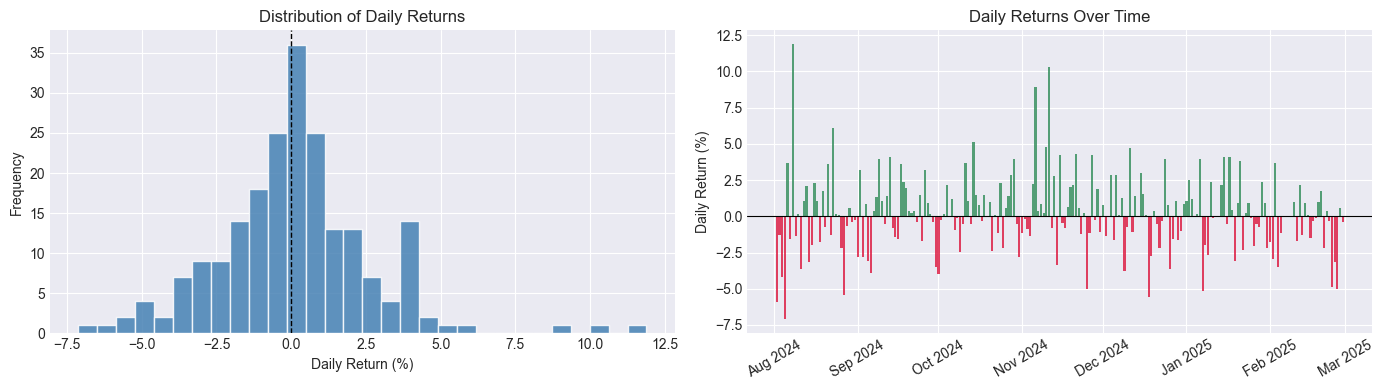

Mean daily return : 0.15%
Std  daily return : 2.61%
Max gain          : 11.88%
Max loss          : -7.12%
Positive days     : 107 / 211


In [7]:
daily_returns = all_data['close'].pct_change().dropna() * 100  # in %

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
ax1.hist(daily_returns, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(0, color='black', linewidth=1, linestyle='--')
ax1.set_xlabel('Daily Return (%)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Daily Returns')

# Over time
ax2.bar(daily_returns.index, daily_returns,
        color=['crimson' if r < 0 else 'seagreen' for r in daily_returns],
        width=0.8, alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Daily Return (%)')
ax2.set_title('Daily Returns Over Time')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('../results/figures/01_daily_returns.png', dpi=150)
plt.show()

print(f"Mean daily return : {daily_returns.mean():.2f}%")
print(f"Std  daily return : {daily_returns.std():.2f}%")
print(f"Max gain          : {daily_returns.max():.2f}%")
print(f"Max loss          : {daily_returns.min():.2f}%")
print(f"Positive days     : {(daily_returns > 0).sum()} / {len(daily_returns)}")